# Compare matching confidence scores for bone marrow atlas

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from os.path import join

In [2]:
adata = sc.read_h5ad(
    "/home/ubuntu/data/dataset-similarity/raw/8674c375-ae3a-433c-97de-3c56cf8f7304.h5ad"
)

In [3]:
del adata.raw

In [4]:
adata.var.index = adata.var["feature_name"].astype(str)

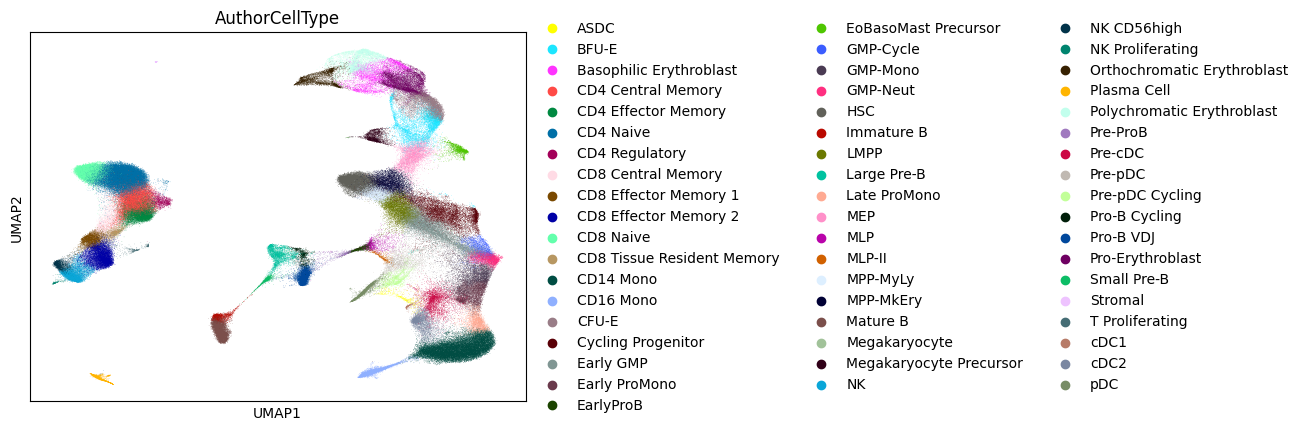

In [5]:
sc.pl.umap(adata, color=["AuthorCellType"])

In [6]:
broad_cts = pd.read_csv("broad_ct_mapping.csv", index_col="AuthorCellType")
adata.obs["AuthorCellTypeBroad"] = adata.obs["AuthorCellType"].astype(str).replace(broad_cts["cell_type"].to_dict())

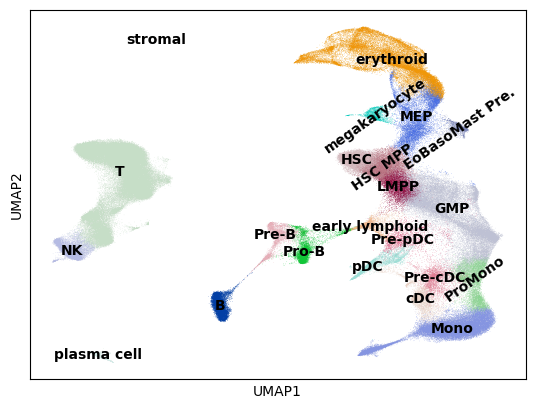

In [20]:
fig = sc.pl.umap(adata, color=["AuthorCellTypeBroad"], legend_loc="on data", legend_fontsize=10, title="", return_fig=True)
for text in fig.get_axes()[0].texts:
    if text.get_text() in ["megakaryocyte", "ProMono", "HSC MPP", "EoBasoMast Pre."]:
        text.set_rotation(35)

plt.savefig("figures/bonemarrow_coarse_celltypes.png", dpi=300, bbox_inches="tight")

## SConnect

In [8]:
mapping_sconnect = pd.read_parquet(join(
    "/home/ubuntu/data/dataset-similarity/models/similarityOT",
    "f6c50495-3361-40ed-a819-fb9644396ed9_updated+"
    "ced320a1-29f3-47c1-a735-513c7084d508_CAP+"
    "n_genes_ova=10+"
    "n_genes_ava=3+"
    "tau=0.95+"
    "epsilon=0.05+"
    "overlap_threshold_ava=0.3+"
    "overlap_n_genes_ava=10",
    "mapping_mean.parquet"
))

In [9]:
distance_sconnect = pd.read_parquet(join(
    "/home/ubuntu/data/dataset-similarity/models/similarityOT",
    "f6c50495-3361-40ed-a819-fb9644396ed9_updated+"
    "ced320a1-29f3-47c1-a735-513c7084d508_CAP+"
    "n_genes_ova=10+"
    "n_genes_ava=3+"
    "tau=0.95+"
    "epsilon=0.05+"
    "overlap_threshold_ava=0.3+"
    "overlap_n_genes_ava=10",
    "distance.parquet"
))

In [10]:
adata.obs["SConnect_confidence"] = adata.obs["AuthorCellType"].astype(str).replace(mapping_sconnect.max(axis=1).to_dict())

/tmp/ipykernel_468416/2167257314.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  adata.obs["SConnect_confidence"] = adata.obs["AuthorCellType"].astype(str).replace(mapping_sconnect.max(axis=1).to_dict())


In [11]:
adata.obs["SConnect_distance"] = adata.obs["AuthorCellType"].astype(str).replace(distance_sconnect.min(axis=1).to_dict())

/tmp/ipykernel_468416/2593636065.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  adata.obs["SConnect_distance"] = adata.obs["AuthorCellType"].astype(str).replace(distance_sconnect.min(axis=1).to_dict())


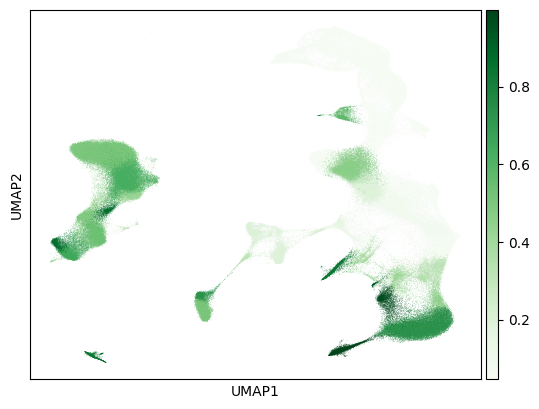

In [21]:
sc.pl.umap(adata, color="SConnect_confidence", color_map="Greens", title="", save="_sconnect_mapping.png")

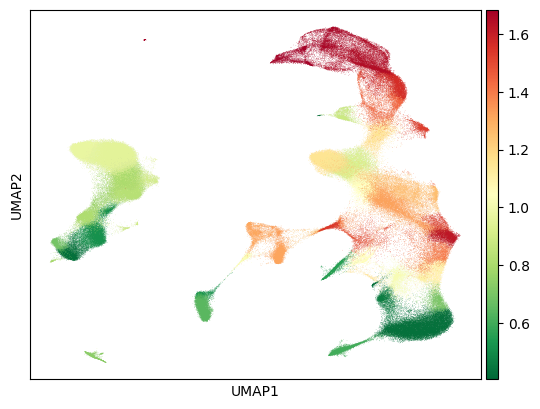

In [22]:
sc.pl.umap(adata, color="SConnect_distance", color_map="RdYlGn_r", title="", save="_sconnect_distance.png")

## CellHint

In [14]:
mapping_cellhint = pd.read_parquet("cellhint_mappping.parquet")
mapping_cellhint.index = mapping_cellhint.index.str.lstrip(" ")

In [15]:
adata.obs["CellHint_confidence"] = adata.obs["AuthorCellType"].astype(str).replace(mapping_cellhint.max(axis=1).to_dict())

/tmp/ipykernel_468416/1289268559.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  adata.obs["CellHint_confidence"] = adata.obs["AuthorCellType"].astype(str).replace(mapping_cellhint.max(axis=1).to_dict())


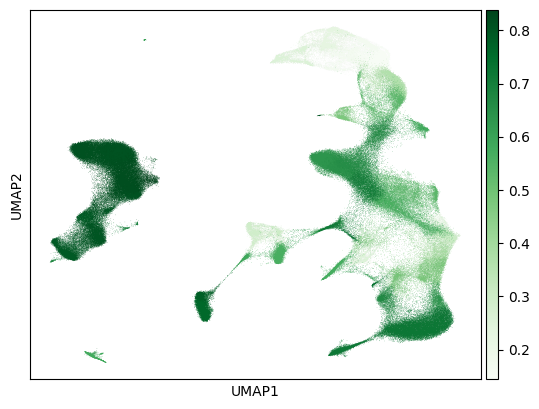

In [23]:
sc.pl.umap(adata, color="CellHint_confidence", color_map="Greens", title="", save="_cellhint_mapping.png")

## MetaNeighbor

In [17]:
mapping_pyMN = pd.read_parquet("pyMN_mapping.parquet")

In [18]:
adata.obs["pyMN_confidence"] = adata.obs["AuthorCellType"].astype(str).replace(mapping_pyMN.max(axis=1).to_dict())

/tmp/ipykernel_468416/2887866263.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  adata.obs["pyMN_confidence"] = adata.obs["AuthorCellType"].astype(str).replace(mapping_pyMN.max(axis=1).to_dict())


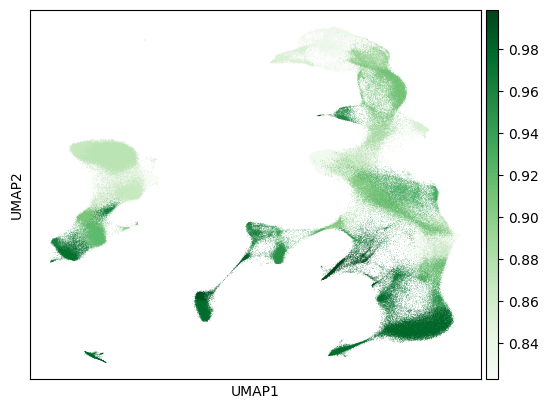

In [24]:
sc.pl.umap(adata, color="pyMN_confidence", color_map="Greens", title="", save="_pyMN_mapping.png")